<a href="https://colab.research.google.com/github/samueltsaii/Personal_Projects/blob/main/Semantic_Liver_Mass_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import json

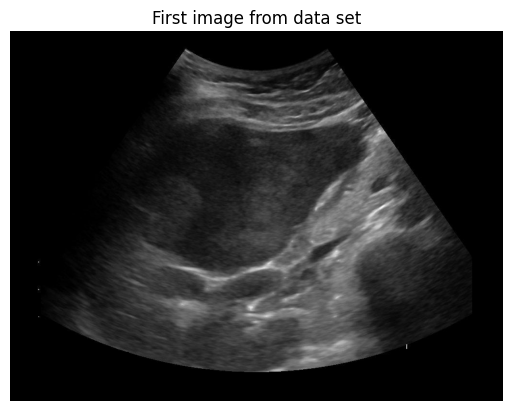

In [127]:
img = cv2.imread("drive/MyDrive/data/Benign/Benign/image/1.jpg")
if img is None:
    print("Error: Image not found")
else:
    img_0 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_0)
    plt.title("First image from data set")
    plt.axis("off")
    plt.show()


In [128]:
base_dir = "drive/MyDrive/data"

categories = ["Benign", "Malignant"]

data = []

for category in categories:
    image_dir = os.path.join(base_dir, category, category, "image")
    seg_dir = os.path.join(base_dir, category, category, "segmentation", "mass")

    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(("png", "jpg", "jpeg"))])
    json_files = sorted([f for f in os.listdir(seg_dir) if f.lower().endswith("json")])

    for img, jsn in zip(image_files, json_files):
        data.append({
            "Category":category,
            "Image_Path":os.path.join(image_dir, img),
            "Segmentation_JSON_Path": os.path.join(seg_dir, jsn)
        })

df = pd.DataFrame(data)

In [129]:
df.head()

,Category,Image_Path,Segmentation_JSON_Path
0,Benign,drive/MyDrive/data/Benign/Benign/image/1.jpg,drive/MyDrive/data/Benign/Benign/segmentation/...
1,Benign,drive/MyDrive/data/Benign/Benign/image/10.jpg,drive/MyDrive/data/Benign/Benign/segmentation/...
2,Benign,drive/MyDrive/data/Benign/Benign/image/100.jpg,drive/MyDrive/data/Benign/Benign/segmentation/...
3,Benign,drive/MyDrive/data/Benign/Benign/image/101.jpg,drive/MyDrive/data/Benign/Benign/segmentation/...
4,Benign,drive/MyDrive/data/Benign/Benign/image/102.jpg,drive/MyDrive/data/Benign/Benign/segmentation/...


In [130]:
df.loc[0]["Segmentation_JSON_Path"]

'drive/MyDrive/data/Benign/Benign/segmentation/mass/1.json'

In [131]:
df.tail()

,Category,Image_Path,Segmentation_JSON_Path
630,Malignant,drive/MyDrive/data/Malignant/Malignant/image/9...,drive/MyDrive/data/Malignant/Malignant/segment...
631,Malignant,drive/MyDrive/data/Malignant/Malignant/image/9...,drive/MyDrive/data/Malignant/Malignant/segment...
632,Malignant,drive/MyDrive/data/Malignant/Malignant/image/9...,drive/MyDrive/data/Malignant/Malignant/segment...
633,Malignant,drive/MyDrive/data/Malignant/Malignant/image/9...,drive/MyDrive/data/Malignant/Malignant/segment...
634,Malignant,drive/MyDrive/data/Malignant/Malignant/image/9...,drive/MyDrive/data/Malignant/Malignant/segment...


In [132]:
df.shape

(635, 3)

In [133]:
df.columns

Index(['Category', 'Image_Path', 'Segmentation_JSON_Path'], dtype='object')

In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
df.isnull().sum()

,0
Category,0
Image_Path,0
Segmentation_JSON_Path,0


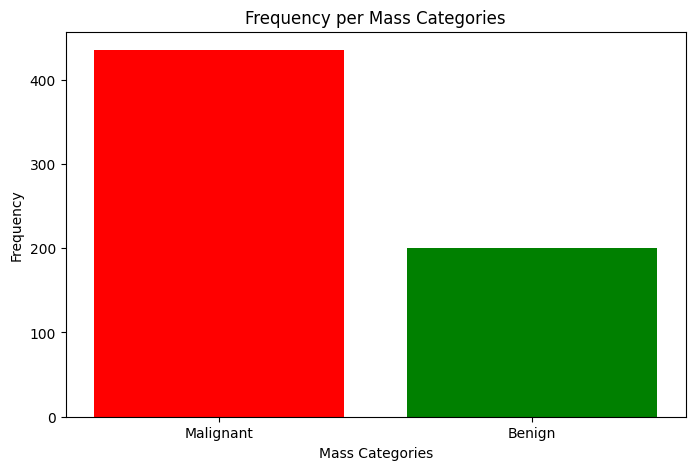

In [136]:
counts = df['Category'].value_counts()

categories = counts.index
frequencies = counts.values

plt.figure(figsize=(8, 5))

colors = ['red' if cat == 'Malignant' else 'green' for cat in categories]

plt.bar(categories, frequencies, color=colors)

plt.xlabel("Mass Categories")

plt.ylabel("Frequency")
plt.title("Frequency per Mass Categories")

plt.show()

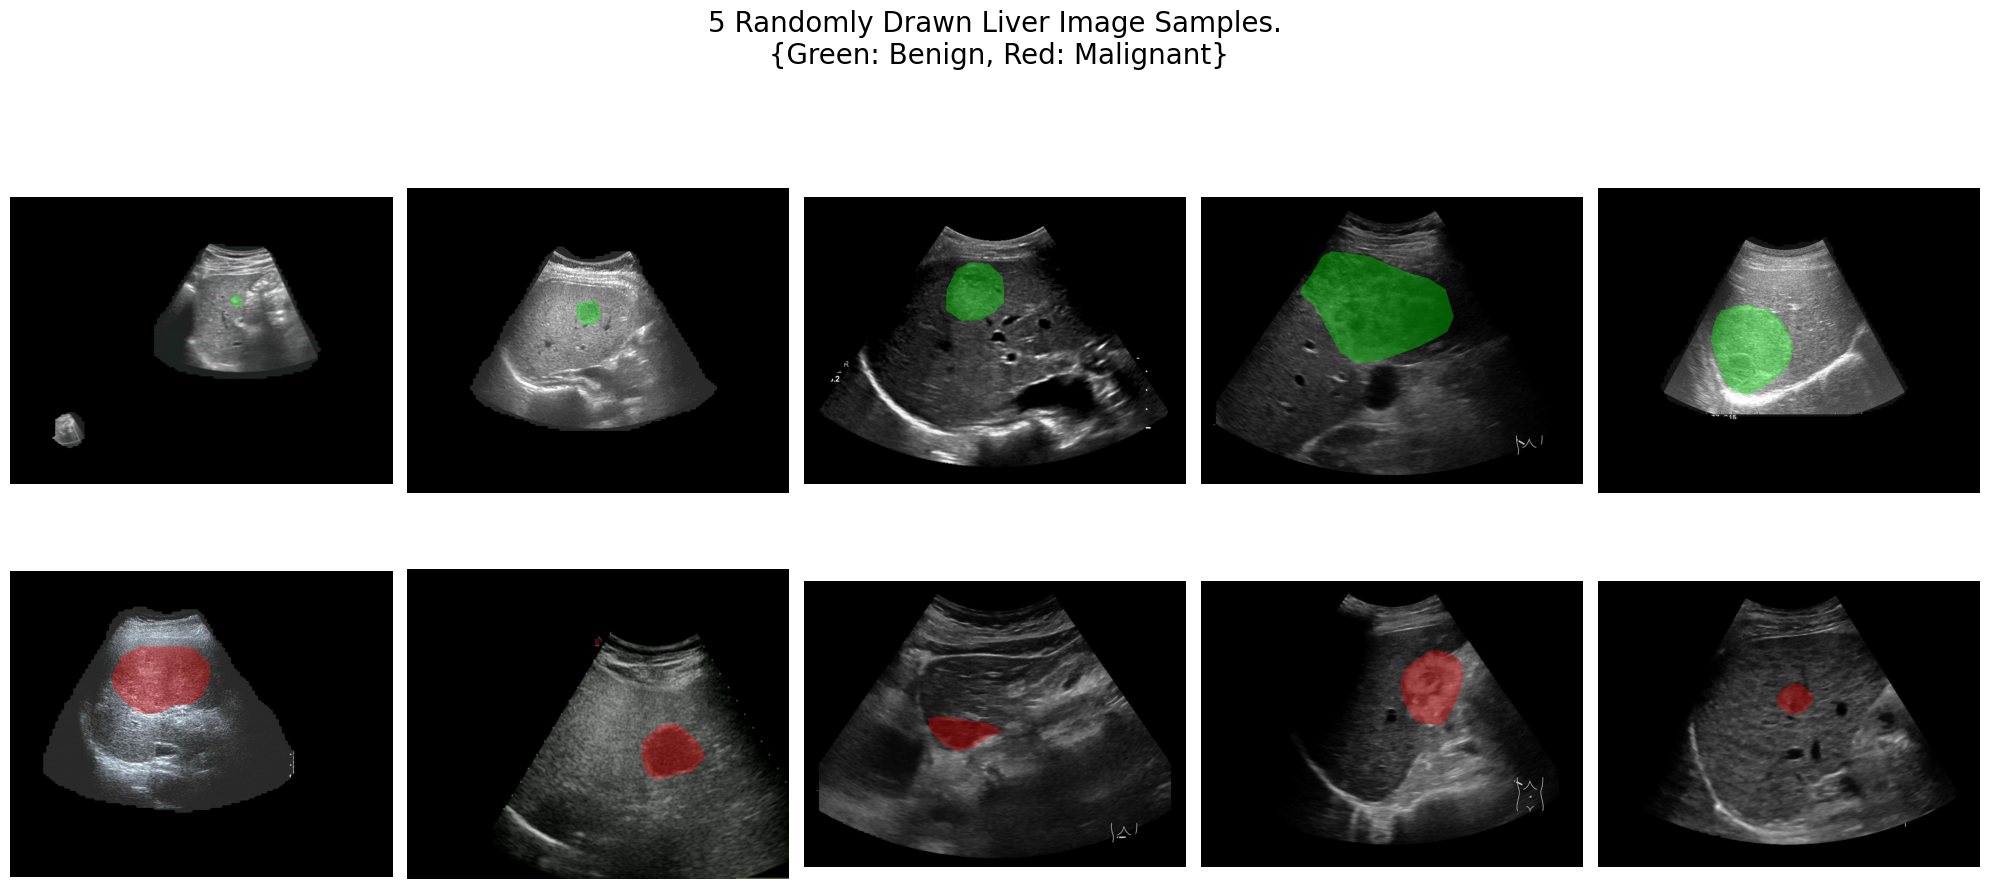

In [137]:
def generate_mask_from_json(json_path, image_shape):
    with open(json_path, 'r') as f:
        points_list = json.load(f)

    mask = np.zeros(image_shape[:2], dtype=np.uint8)

    points = np.array(points_list, dtype=np.int32)

    if len(points) >= 3:
        cv2.fillPoly(mask, [points], 255)

    return mask

def display_images_with_masks(df):
    categories = df['Category'].unique()
    fig, axes = plt.subplots(len(categories), 5, figsize=(20, 10))
    fig.suptitle("5 Randomly Drawn Liver Image Samples.\n {Green: Benign, Red: Malignant}", fontsize=20)

    for row_idx, category in enumerate(categories):

        samples = df[df['Category'] == category].sample(5, random_state=42).reset_index(drop=True)

        for col_idx, row in samples.iterrows():
            img = cv2.imread(row['Image_Path'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            try:
                mask = generate_mask_from_json(row['Segmentation_JSON_Path'], img.shape)
            except Exception as e:
                print(f"Error reading mask for {row['Segmentation_JSON_Path']}: {e}")
                mask = np.zeros(img.shape[:2], dtype=np.uint8)

            overlay = img.copy()
            alpha = 0.65
            beta = 0.35
            colour = [255, 0, 0] if 'Malignant' in row["Category"] else [0, 255, 0]
            overlay[mask == 255] = colour
            transparent_image = cv2.addWeighted(img, alpha, overlay, beta, 0)

            axes[row_idx, col_idx].imshow(transparent_image)
            axes[row_idx, col_idx].axis('off')

            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(category, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

display_images_with_masks(df)

In [138]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.v2 as transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

In [139]:
class Unet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c), # Added BatchNorm
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c), # Added BatchNorm
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.e1 = conv_block(3, 16)
        self.e2 = conv_block(16, 32)
        self.e3 = conv_block(32, 64)
        self.e4 = conv_block(64, 128)
        self.e5 = conv_block(128, 256)

        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.up4 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.d4 = conv_block(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.d3 = conv_block(128, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.d2 = conv_block(64, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, 2, 2)
        self.d1 = conv_block(32, 16)

        self.outconv = nn.Conv2d(16, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        c1 = self.e1(x)
        p1 = self.pool(c1)

        c2 = self.e2(p1)
        p2 = self.pool(c2)

        c3 = self.e3(p2)
        p3 = self.pool(c3)

        c4 = self.e4(p3)
        p4 = self.pool(c4)

        # Bridge
        c5 = self.e5(p4)

        # Decoder
        u4 = self.up4(c5)
        u4 = torch.cat([u4, c4], dim=1)
        d4 = self.d4(u4)

        u3 = self.up3(d4)
        u3 = torch.cat([u3, c3], dim=1)
        d3 = self.d3(u3)

        u2 = self.up2(d3)
        u2 = torch.cat([u2, c2], dim=1)
        d2 = self.d2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, c1], dim=1)
        d1 = self.d1(u1)

        return self.outconv(d1)

In [140]:
class LiverSegmentationDataset(Dataset):
    def __init__(self, dataframe, image_key, annotation_key, transform = None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images = dataframe[image_key]
        self.annotations = dataframe[annotation_key]
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = generate_mask_from_json(self.annotations[idx], image.shape)

        image = Image.fromarray(image)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

In [141]:
# Adding early stopping
import copy

class EarlyStopping():
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_weights = None
        self.best_loss = None
        self.counter = 0
        self.status = ''

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            # Save weights to CPU to save GPU memory
            self.best_weights = copy.deepcopy(model.state_dict())
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.status = f'Stopped on {self.counter} steps with loss: {val_loss}'
                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)
                return True

        self.status = f'Patience: {self.counter}/{self.patience} | Best Loss: {self.best_loss:.4f}'
        return False

In [142]:
# Instantiate dice coefficients
def dice_coef(preds, targets, smooth=1e-6):
    preds = torch.argmax(preds, dim=1)
    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2.0 * intersection + smooth) / (preds.sum() + targets.sum() + smooth)
    return dice

In [143]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

data_set = LiverSegmentationDataset(df, "Image_Path", "Segmentation_JSON_Path", transform)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [144]:
train_size = int(0.8 * len(data_set))
valid_size = len(data_set) - train_size

train_data_set, valid_data_set = random_split(data_set, [train_size, valid_size])

In [145]:
train_loader = DataLoader(train_data_set, batch_size = 64, shuffle = True)
valid_loader = DataLoader(valid_data_set, batch_size = 64, shuffle = False)

In [146]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = F.softmax(inputs, dim=1)
        inputs = inputs[:, 1, :, :].reshape(-1)
        targets = targets.reshape(-1).float()

        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')

        return BCE + dice_loss

In [147]:
#Instantiating hyperparameters
model = Unet(n_classes = 2)
Epochs = 40
learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr= learning_rate)
criterion = DiceBCELoss()
es = EarlyStopping()

In [148]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)
train_losses, valid_losses = [], []

for Epoch in range(Epochs):
    model.train()
    train_running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        labels = labels.squeeze(1).to(device=device, dtype=torch.long)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_running_loss += loss.item() * images.size(0)

    epoch_train_loss = train_running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    all_labels = []
    all_probs = []
    valid_running_loss = 0.0
    valid_running_dice = 0.0
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.squeeze(1).to(device=device, dtype=torch.long)

            outputs = model(images)

            probs = F.softmax(outputs, dim = 1)
            liver_probs = probs[:, 1, :, :]

            batch_dice = dice_coef(outputs, labels)
            valid_running_dice += batch_dice.item() * images.size(0)

            all_probs.append(liver_probs.cpu().numpy().flatten())
            all_labels.append(labels.cpu().numpy().flatten())

            loss = criterion(outputs, labels)
            valid_running_loss += loss.item() * images.size(0)

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    auc_score = roc_auc_score(all_labels, all_probs)

    epoch_valid_loss = valid_running_loss / len(valid_loader.dataset)
    epoch_valid_dice = valid_running_dice / len(valid_loader.dataset)
    valid_losses.append(epoch_valid_loss)
    stop_training = es(model, epoch_valid_loss)

    if stop_training:
        print(es.status)
        break

    print(f"ROC-AUC Score: {auc_score:.4f}")
    print(f'Epoch {Epoch + 1}/{Epochs} | Train Loss: {epoch_train_loss:.4f} | Valid Loss: {epoch_valid_loss:.4f}')
    print(f'Val Dice: {epoch_valid_dice:.4f} | Val AUC: {auc_score:.4f}')
    print('-' * 20)


ROC-AUC Score: 0.4564
Epoch 1/40 | Train Loss: 1.5448 | Valid Loss: 1.5412
Val Dice: 0.0000 | Val AUC: 0.4564
--------------------
ROC-AUC Score: 0.5059
Epoch 2/40 | Train Loss: 1.5386 | Valid Loss: 1.5349
Val Dice: 0.0000 | Val AUC: 0.5059
--------------------
ROC-AUC Score: 0.5539
Epoch 3/40 | Train Loss: 1.5315 | Valid Loss: 1.5269
Val Dice: 0.0000 | Val AUC: 0.5539
--------------------


KeyboardInterrupt: 

In [ ]:
def visualize_results(model, dataloader, device, num_samples=3):
    model.eval()
    images, labels = next(iter(dataloader))

    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

    plt.figure(figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(images[i].cpu().permute(1, 2, 0))
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(labels[i].cpu().squeeze(), cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis('off')

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i].cpu(), cmap='Purples', alpha=0.5)
        plt.title("Predicted Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('sample_predictions.png')

visualize_results(model, valid_loader, device)